# Location-Based Cluster Sample

This notebook compares rodent measurements across different locations. Instead of grouping observations by species, this notebook groups observations by the plots they came from. Each location cluster contains a couple of plots, then the sample takes the same number of observations from each cluster.

The main question is: **Do weight and hindfoot length look different depending on where the observations were collected?**


---


## Load the data

This cell reads the merged project dataset and creates the plot clusters that will be used for sampling. The clusters are built from pairs of plots so each sampled group represents a small location area instead of one single plot.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 123
OBSERVATIONS_PER_CLUSTER = 120

CLUSTER_LOOKUP = {
    1: 'Spectab plots 1 and 9',
    9: 'Spectab plots 1 and 9',
    2: 'Control plots 2 and 4',
    4: 'Control plots 2 and 4',
    8: 'Control plots 8 and 11',
    11: 'Control plots 8 and 11',
    12: 'Control plots 12 and 14',
    14: 'Control plots 12 and 14',
    17: 'Control plots 17 and 22',
    22: 'Control plots 17 and 22',
    3: 'Long-term Krat plots 3 and 15',
    15: 'Long-term Krat plots 3 and 15',
    19: 'Long-term Krat plots 19 and 21',
    21: 'Long-term Krat plots 19 and 21',
    5: 'Rodent plots 5 and 7',
    7: 'Rodent plots 5 and 7',
    10: 'Rodent plots 10 and 16',
    16: 'Rodent plots 10 and 16',
    23: 'Rodent plots 23 and 24',
    24: 'Rodent plots 23 and 24',
    6: 'Short-term Krat plots 6 and 13',
    13: 'Short-term Krat plots 6 and 13',
    18: 'Short-term Krat plots 18 and 20',
    20: 'Short-term Krat plots 18 and 20',
}

CLUSTER_ORDER = list(dict.fromkeys(CLUSTER_LOOKUP.values()))

# Load the merged project dataset
df = pd.read_csv('../../output/merged_full.csv')
df.head()


,record_id,month,day,year,plot_id,note1,species_id,sex,hindfoot_length,weight,genus,species_name,taxa,plot_type,note1_meaning
0,63,8,19,1977,3.0,NaN,DM,M,35.0,40.0,Dipodomys,merriami,Rodent,Long-term Krat Exclosure,NaN
1,64,8,19,1977,7.0,NaN,DM,M,37.0,48.0,Dipodomys,merriami,Rodent,Rodent Exclosure,NaN
2,65,8,19,1977,4.0,NaN,DM,F,34.0,29.0,Dipodomys,merriami,Rodent,Control,NaN
3,66,8,19,1977,4.0,NaN,DM,F,35.0,46.0,Dipodomys,merriami,Rodent,Control,NaN
4,67,8,19,1977,7.0,NaN,DM,M,35.0,36.0,Dipodomys,merriami,Rodent,Rodent Exclosure,NaN


The merged dataset includes species information, measurement columns, and plot information. For this lesson, the most important columns are **plot_id**, **plot_type**, **weight**, and **hindfoot_length**, because the sample is based on where each observation was collected.


In [29]:
print('Unique plot types in the dataset:')
print(list(df['plot_type'].unique()))

print("\nUnique plot IDs in the dataset:")
print(list(df['plot_id'].unique()))

Unique plot types in the dataset:
['Long-term Krat Exclosure', 'Rodent Exclosure', 'Control', 'Spectab exclosure', 'Short-term Krat Exclosure', nan]

Unique plot IDs in the dataset:
[3.0, 7.0, 4.0, 8.0, 2.0, 1.0, 6.0, 19.0, 23.0, 18.0, 5.0, 12.0, 11.0, 13.0, 20.0, 22.0, 17.0, 14.0, 16.0, 9.0, 21.0, 15.0, 24.0, 10.0, nan]


## Prepare the location sampling dataset

This cell keeps the columns needed for the location comparison and assigns each observation to a location cluster.


In [18]:
location_df = df[[
    'record_id',
    'year',
    'month',
    'species_id',
    'species_name',
    'sex',
    'plot_id',
    'plot_type',
    'hindfoot_length',
    'weight'
]].copy()

for col in ['species_id', 'species_name', 'sex', 'plot_type']:
    location_df[col] = location_df[col].astype('string').str.strip()

location_df['plot_id'] = location_df['plot_id'].astype('Int64')
location_df['location_cluster'] = location_df['plot_id'].map(CLUSTER_LOOKUP)

location_df = location_df.dropna(
    subset=['plot_id', 'plot_type', 'location_cluster', 'hindfoot_length', 'weight']
).copy()

location_df['location_cluster'] = pd.Categorical(
    location_df['location_cluster'],
    categories=CLUSTER_ORDER,
    ordered=True
)

location_df.head()


,record_id,year,month,species_id,species_name,sex,plot_id,plot_type,hindfoot_length,weight,location_cluster
0,63,1977,8,DM,merriami,M,3,Long-term Krat Exclosure,35.0,40.0,Long-term Krat plots 3 and 15
1,64,1977,8,DM,merriami,M,7,Rodent Exclosure,37.0,48.0,Rodent plots 5 and 7
2,65,1977,8,DM,merriami,F,4,Control,34.0,29.0,Control plots 2 and 4
3,66,1977,8,DM,merriami,F,4,Control,35.0,46.0,Control plots 2 and 4
4,67,1977,8,DM,merriami,M,7,Rodent Exclosure,35.0,36.0,Rodent plots 5 and 7


The location cluster is the group that controls the sample. A plot by itself can be too narrow, so the clusters combine nearby or related plots into pairs. This keeps the analysis location based while still giving each group enough records to sample from.


## Start with the full dataset truth

Before sampling anything, we should inspect the full location dataset. The full dataset shows how many observations are available across the plots and clusters before we balance the sample.


In [19]:
print(f"There are {len(location_df)} observations with plot, weight, and hindfoot length data")
print(f"There are {location_df['plot_id'].nunique()} plots")
print(f"There are {location_df['location_cluster'].nunique()} location clusters")

location_df[['plot_id', 'plot_type', 'location_cluster', 'hindfoot_length', 'weight']].head()


There are 70916 observations with plot, weight, and hindfoot length data
There are 24 plots
There are 12 location clusters


,plot_id,plot_type,location_cluster,hindfoot_length,weight
0,3,Long-term Krat Exclosure,Long-term Krat plots 3 and 15,35.0,40.0
1,7,Rodent Exclosure,Rodent plots 5 and 7,37.0,48.0
2,4,Control,Control plots 2 and 4,34.0,29.0
3,4,Control,Control plots 2 and 4,35.0,46.0
4,7,Rodent Exclosure,Rodent plots 5 and 7,35.0,36.0


This is the baseline that the cluster sample should be compared against. If the goal is to estimate the whole dataset, the sample should look similar to this full dataset. If the goal is to compare locations, the sample may intentionally balance the clusters.


## Count observations by location cluster

Before cluster sampling, we need to know whether each location cluster has enough records. A cluster sample with 120 observations per cluster can only include clusters that have at least 120 observations.


In [20]:
cluster_counts = (
    location_df.groupby(['location_cluster', 'plot_type'], observed=True)
    .agg(
        full_dataset_count=('record_id', 'size'),
        number_plots=('plot_id', 'nunique'),
        mean_hindfoot_length=('hindfoot_length', 'mean'),
        median_hindfoot_length=('hindfoot_length', 'median'),
        mean_weight=('weight', 'mean'),
        median_weight=('weight', 'median')
    )
    .reset_index()
)

cluster_counts['full_dataset_percent'] = (
    cluster_counts['full_dataset_count'] / cluster_counts['full_dataset_count'].sum()
)

cluster_counts.sort_values('full_dataset_count', ascending=False)


,location_cluster,plot_type,full_dataset_count,number_plots,mean_hindfoot_length,median_hindfoot_length,mean_weight,median_weight,full_dataset_percent
1,Control plots 2 and 4,Control,8428,2,28.290460,26.0,35.259848,31.0,0.118845
2,Control plots 8 and 11,Control,7787,2,29.412739,33.0,36.676384,35.0,0.109806
3,Control plots 12 and 14,Control,7678,2,29.824043,35.0,36.651732,40.0,0.108269
4,Control plots 17 and 22,Control,7225,2,28.927474,27.0,36.895502,33.0,0.101881
0,Spectab plots 1 and 9,Spectab exclosure,6848,2,30.221086,34.0,39.612588,38.0,0.096565
10,Short-term Krat plots 6 and 13,Short-term Krat Exclosure,6371,2,25.749490,23.0,30.539790,25.0,0.089839
5,Long-term Krat plots 3 and 15,Long-term Krat Exclosure,6083,2,22.825086,22.0,24.203847,20.0,0.085778
11,Short-term Krat plots 18 and 20,Short-term Krat Exclosure,5856,2,25.180669,23.0,30.076332,25.0,0.082577
6,Long-term Krat plots 19 and 21,Long-term Krat Exclosure,5436,2,22.234731,22.0,23.561626,20.0,0.076654
7,Rodent plots 5 and 7,Rodent Exclosure,4385,2,25.925656,22.0,29.939795,24.0,0.061834


The full dataset is not perfectly balanced across location clusters. Some plot pairs have many more observations than others. This imbalance is the main reason a location-based sample can be useful when the question is about comparing places.


## Create the sampling frame

This cell keeps only the location clusters with enough observations for the equal-size cluster sample. This makes the comparison cleaner because every eligible cluster contributes the same number of observations.


In [21]:
eligible_clusters = cluster_counts.loc[
    cluster_counts['full_dataset_count'] >= OBSERVATIONS_PER_CLUSTER,
    'location_cluster'
]

sampling_frame = location_df[location_df['location_cluster'].isin(eligible_clusters)].copy()
n_clusters = sampling_frame['location_cluster'].nunique()
total_sample_size = n_clusters * OBSERVATIONS_PER_CLUSTER

print(f"There are {n_clusters} eligible location clusters")
print(f"The cluster sample will contain {total_sample_size} total observations")


There are 12 eligible location clusters
The cluster sample will contain 1440 total observations


The sampling frame is the population that this location-based sample will draw from. Using the same number of rows from each cluster lets the comparison focus on location instead of on which plots were sampled most often in the original data.


## Sample from each location cluster

This cell samples the same number of observations from every eligible location cluster. The clusters are defined by *location_cluster*, and the random seed is set to *123*.


In [22]:
cluster_sample = (
    sampling_frame
    .groupby('location_cluster', observed=True, group_keys=False)
    .sample(n=OBSERVATIONS_PER_CLUSTER, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

cluster_sample.head()


,record_id,year,month,species_id,species_name,sex,plot_id,plot_type,hindfoot_length,weight,location_cluster
0,11073,1985,11,DS,spectabilis,M,1,Spectab exclosure,52.0,125.0,Spectab plots 1 and 9
1,55320,2012,6,DM,merriami,F,9,Spectab exclosure,36.0,39.0,Spectab plots 1 and 9
2,56379,2012,10,PB,baileyi,M,1,Spectab exclosure,25.0,28.0,Spectab plots 1 and 9
3,64115,2015,10,OT,torridus,F,1,Spectab exclosure,19.0,21.0,Spectab plots 1 and 9
4,5172,1982,1,DS,spectabilis,M,1,Spectab exclosure,53.0,160.0,Spectab plots 1 and 9


A cluster sample is more planned than a simple random sample. It requires us to define the location groups first, then sample within each group. This creates a balanced sample by location cluster, even when the full dataset is uneven.


## Compare cluster representation

This cell compares how many observations each location cluster contributes to the full sampling frame and to the cluster sample. It includes both raw counts and proportions so the imbalance is visible.


In [23]:
representation_df = pd.DataFrame({
    'full_dataset_count': sampling_frame['location_cluster'].value_counts(sort=False),
    'cluster_sample_count': cluster_sample['location_cluster'].value_counts(sort=False)
}).fillna(0)

representation_df['full_dataset_percent'] = (
    representation_df['full_dataset_count'] / representation_df['full_dataset_count'].sum()
)
representation_df['cluster_sample_percent'] = (
    representation_df['cluster_sample_count'] / representation_df['cluster_sample_count'].sum()
)

representation_df = representation_df.astype({
    'full_dataset_count': int,
    'cluster_sample_count': int
})

representation_df


,full_dataset_count,cluster_sample_count,full_dataset_percent,cluster_sample_percent
location_cluster,,,,
Spectab plots 1 and 9,6848,120,0.096565,0.083333
Control plots 2 and 4,8428,120,0.118845,0.083333
Control plots 8 and 11,7787,120,0.109806,0.083333
Control plots 12 and 14,7678,120,0.108269,0.083333
Control plots 17 and 22,7225,120,0.101881,0.083333
Long-term Krat plots 3 and 15,6083,120,0.085778,0.083333
Long-term Krat plots 19 and 21,5436,120,0.076654,0.083333
Rodent plots 5 and 7,4385,120,0.061834,0.083333
Rodent plots 10 and 16,1687,120,0.023789,0.083333


The full dataset has uneven cluster representation because some plots were observed more often than others. The cluster sample is flat because it was designed to include exactly 120 observations per location cluster.


Every location cluster contributes the same number of observations to the sample. That makes the sample useful for comparing clusters, because one heavily observed location cannot dominate the analysis.


## Compare measurement summaries

This cell compares the average and median hindfoot length and weight across the location clusters in the full sampling frame.


In [25]:
cluster_summary_df = (
    sampling_frame.groupby(['location_cluster', 'plot_type'], observed=True)
    .agg(
        number_observations=('record_id', 'size'),
        number_plots=('plot_id', 'nunique'),
        mean_hindfoot_length=('hindfoot_length', 'mean'),
        median_hindfoot_length=('hindfoot_length', 'median'),
        mean_weight=('weight', 'mean'),
        median_weight=('weight', 'median')
    )
    .reset_index()
)

cluster_summary_df.round(2)


,location_cluster,plot_type,number_observations,number_plots,mean_hindfoot_length,median_hindfoot_length,mean_weight,median_weight
0,Spectab plots 1 and 9,Spectab exclosure,6848,2,30.22,34.0,39.61,38.0
1,Control plots 2 and 4,Control,8428,2,28.29,26.0,35.26,31.0
2,Control plots 8 and 11,Control,7787,2,29.41,33.0,36.68,35.0
3,Control plots 12 and 14,Control,7678,2,29.82,35.0,36.65,40.0
4,Control plots 17 and 22,Control,7225,2,28.93,27.0,36.90,33.0
5,Long-term Krat plots 3 and 15,Long-term Krat Exclosure,6083,2,22.83,22.0,24.20,20.0
6,Long-term Krat plots 19 and 21,Long-term Krat Exclosure,5436,2,22.23,22.0,23.56,20.0
7,Rodent plots 5 and 7,Rodent Exclosure,4385,2,25.93,22.0,29.94,24.0
8,Rodent plots 10 and 16,Rodent Exclosure,1687,2,21.67,20.0,21.56,18.0
9,Rodent plots 23 and 24,Rodent Exclosure,3132,2,24.31,21.0,27.15,22.0


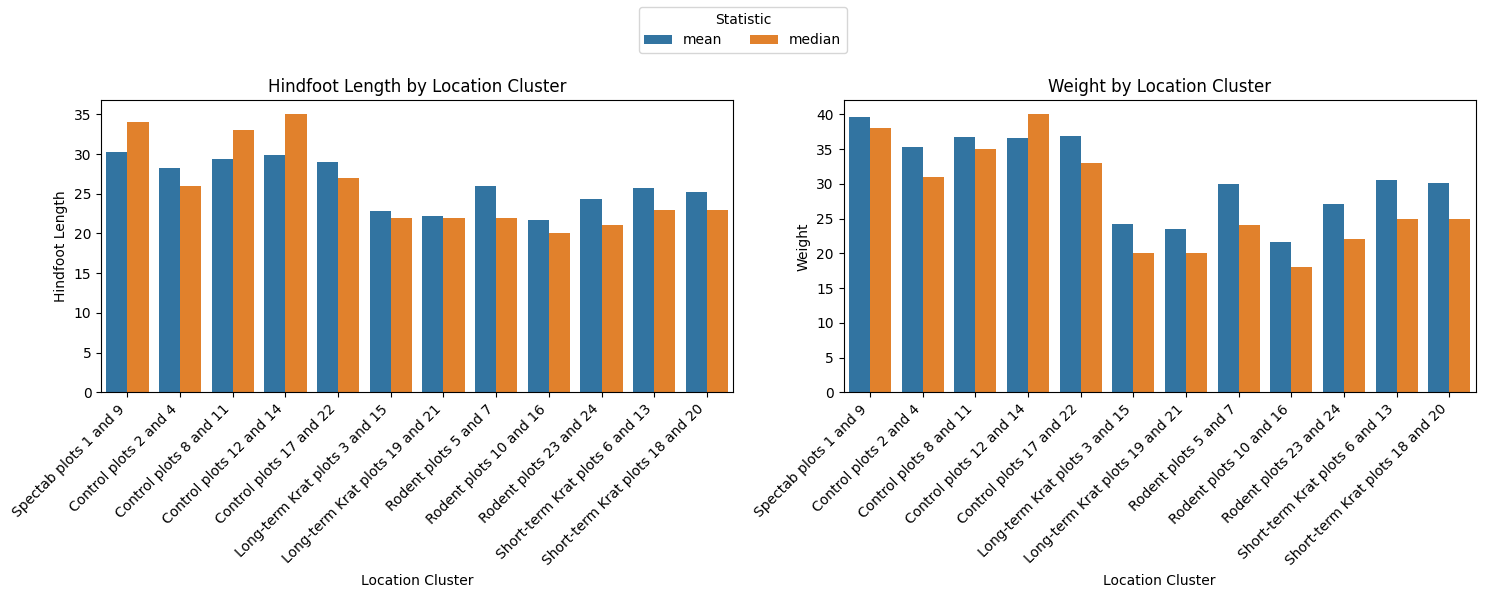

In [26]:
# FIG 5.2

summary_plot_df = cluster_summary_df.melt(
    id_vars=['location_cluster', 'plot_type'],
    value_vars=[
        'mean_hindfoot_length',
        'median_hindfoot_length',
        'mean_weight',
        'median_weight'
    ],
    var_name='metric',
    value_name='value'
)

summary_plot_df['statistic'] = summary_plot_df['metric'].str.extract(r'^(mean|median)')
summary_plot_df['measurement'] = summary_plot_df['metric'].str.replace(r'^(mean|median)_', '', regex=True)
summary_plot_df['location_cluster'] = summary_plot_df['location_cluster'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=summary_plot_df[summary_plot_df['measurement'] == 'hindfoot_length'],
    x='location_cluster',
    y='value',
    hue='statistic',
    ax=axes[0]
)
axes[0].set_title('Hindfoot Length by Location Cluster')
axes[0].set_xlabel('Location Cluster')
axes[0].set_ylabel('Hindfoot Length')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(
    data=summary_plot_df[summary_plot_df['measurement'] == 'weight'],
    x='location_cluster',
    y='value',
    hue='statistic',
    ax=axes[1]
)
axes[1].set_title('Weight by Location Cluster')
axes[1].set_xlabel('Location Cluster')
axes[1].set_ylabel('Weight')
axes[1].tick_params(axis='x', rotation=45)

for ax in axes:
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend_.remove()
axes[1].legend_.remove()
fig.legend(handles, labels, title='Statistic', loc='upper center', ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()


The location clusters do not all have the same measurement profile. Some clusters have higher average weight, while others have smaller hindfoot length values. The mean and median together help show whether a cluster is being pulled by unusually large or small measurements.


## Compare the sample back to the full clusters

A location-based sample should still be checked against the full data. This cell compares the full cluster averages to the sampled cluster averages for weight and hindfoot length.


In [27]:
full_cluster_summary = (
    sampling_frame.groupby('location_cluster', observed=True)
    .agg(
        full_number=('record_id', 'size'),
        full_mean_hindfoot_length=('hindfoot_length', 'mean'),
        full_mean_weight=('weight', 'mean')
    )
)

sample_cluster_summary = (
    cluster_sample.groupby('location_cluster', observed=True)
    .agg(
        sample_number=('record_id', 'size'),
        sample_mean_hindfoot_length=('hindfoot_length', 'mean'),
        sample_mean_weight=('weight', 'mean')
    )
)

cluster_level_comparison = full_cluster_summary.join(sample_cluster_summary)
cluster_level_comparison.round(2)


,full_number,full_mean_hindfoot_length,full_mean_weight,sample_number,sample_mean_hindfoot_length,sample_mean_weight
location_cluster,,,,,,
Spectab plots 1 and 9,6848,30.22,39.61,120,29.71,40.27
Control plots 2 and 4,8428,28.29,35.26,120,27.42,34.52
Control plots 8 and 11,7787,29.41,36.68,120,29.38,36.08
Control plots 12 and 14,7678,29.82,36.65,120,28.58,35.51
Control plots 17 and 22,7225,28.93,36.90,120,27.59,35.16
Long-term Krat plots 3 and 15,6083,22.83,24.20,120,22.24,23.42
Long-term Krat plots 19 and 21,5436,22.23,23.56,120,21.90,22.90
Rodent plots 5 and 7,4385,25.93,29.94,120,25.22,28.90
Rodent plots 10 and 16,1687,21.67,21.56,120,21.18,20.20


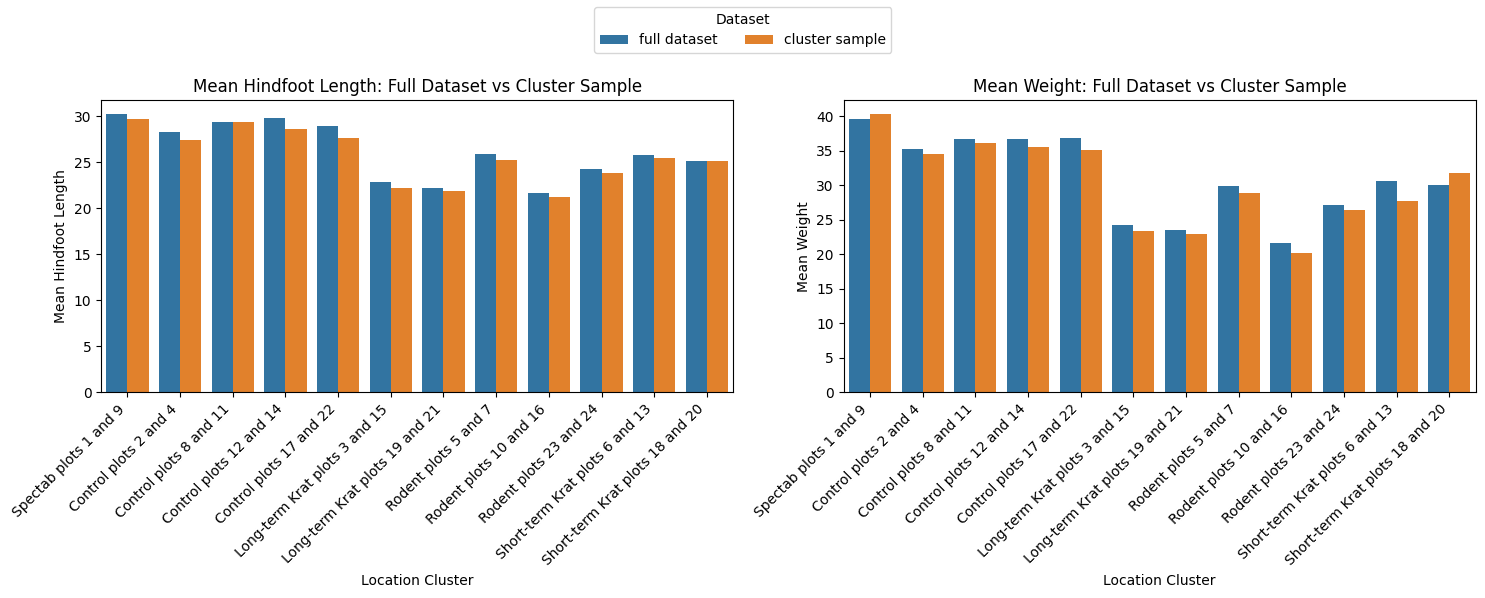

In [28]:
# FIG 5.3

comparison_plot_df = (
    cluster_level_comparison
    .reset_index()
    .melt(
        id_vars='location_cluster',
        value_vars=[
            'full_mean_hindfoot_length',
            'sample_mean_hindfoot_length',
            'full_mean_weight',
            'sample_mean_weight'
        ],
        var_name='metric',
        value_name='value'
    )
)

comparison_plot_df['dataset'] = comparison_plot_df['metric'].str.extract(r'^(full|sample)')
comparison_plot_df['measurement'] = comparison_plot_df['metric'].str.replace(r'^(full|sample)_mean_', '', regex=True)
comparison_plot_df['dataset'] = comparison_plot_df['dataset'].replace({
    'full': 'full dataset',
    'sample': 'cluster sample'
})
comparison_plot_df['location_cluster'] = comparison_plot_df['location_cluster'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=comparison_plot_df[comparison_plot_df['measurement'] == 'hindfoot_length'],
    x='location_cluster',
    y='value',
    hue='dataset',
    ax=axes[0]
)
axes[0].set_title('Mean Hindfoot Length: Full Dataset vs Cluster Sample')
axes[0].set_xlabel('Location Cluster')
axes[0].set_ylabel('Mean Hindfoot Length')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(
    data=comparison_plot_df[comparison_plot_df['measurement'] == 'weight'],
    x='location_cluster',
    y='value',
    hue='dataset',
    ax=axes[1]
)
axes[1].set_title('Mean Weight: Full Dataset vs Cluster Sample')
axes[1].set_xlabel('Location Cluster')
axes[1].set_ylabel('Mean Weight')
axes[1].tick_params(axis='x', rotation=45)

for ax in axes:
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend_.remove()
axes[1].legend_.remove()
fig.legend(handles, labels, title='Dataset', loc='upper center', ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()


The sampled values should be close to the full cluster values if the sample represents each cluster well. Small differences are expected because the sample only uses part of the data, but large differences would be a warning that the sample may not describe that cluster very well.


## Choose the sample based on the question

If the question is **What is the average weight of rodents overall?**, a simple random sample is usually better because it preserves the natural population proportions.

If the question is **How do different locations compare?**, a location-based cluster sample is useful because each cluster gets equal space in the analysis. This makes the comparison between locations more direct.


## Conclusion

**Location-Based Cluster Sample**

- useful when the goal is to compare observations across plot locations.
- gives every location cluster the same number of sampled observations.
- helps compare weight and hindfoot length without letting the most observed plots dominate the results.

The main tradeoff is that the sample is no longer trying to copy the full dataset exactly. It is built for comparison between locations, not for estimating the overall dataset average.
